# DAY 6 - TASK 1
# Historical Value at Risk (VaR) and Conditional VaR (CVaR)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav_data = pd.read_csv("../data/processed/clean_nav_history.csv")
scheme_data = pd.read_csv("../data/processed/clean_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")
holdings_data = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
nav_data["date"] = pd.to_datetime(nav_data["date"])
nav_data = nav_data.sort_values(by=["amfi_code", "date"])
nav_data["daily_return"] = (nav_data.groupby("amfi_code")["nav"].pct_change())
returns_data = nav_data.dropna(subset=["daily_return"]).copy()
returns_data.head()

,date,amfi_code,nav,daily_return
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000


In [5]:
risk_records = []
for fund_code, fund_frame in returns_data.groupby("amfi_code"):
    fund_returns = fund_frame["daily_return"]
    var_95 = np.percentile(fund_returns,5)
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    risk_records.append({"amfi_code": fund_code,"var_95": var_95,"cvar_95": cvar_95,
        "num_observations": len(fund_returns)}
        )

In [6]:
var_cvar_report = pd.DataFrame(risk_records)
var_cvar_report.head()

,amfi_code,var_95,cvar_95,num_observations
0,100016,-0.012884,-0.016768,1607
1,100025,-0.003338,-0.004581,1607
2,100033,-0.016902,-0.021850,1607
3,101206,-0.012173,-0.016075,1607
4,101207,-0.023915,-0.030289,1607


In [7]:
scheme_data = scheme_data[["amfi_code", "scheme_name"]]
var_cvar_report = (var_cvar_report.merge(
                    scheme_data,
                    on="amfi_code",
                    how="left"
                    )
)

In [8]:
var_cvar_report = var_cvar_report[[
        "amfi_code",
        "scheme_name",
        "var_95",
        "cvar_95",
        "num_observations"
    ]
]
var_cvar_report.head()

,amfi_code,scheme_name,var_95,cvar_95,num_observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.012884,-0.016768,1607
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003338,-0.004581,1607
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.016902,-0.021850,1607
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.012173,-0.016075,1607
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289,1607


In [9]:
highest_risk_funds = (var_cvar_report.sort_values(by="var_95"))
highest_risk_funds.head(10)

,amfi_code,scheme_name,var_95,cvar_95,num_observations
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289,1607
17,119095,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690,1607
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163,1607
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940,1607
39,149324,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573,1607
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.021502,-0.028444,1607
16,119094,Axis Midcap Fund - Regular - Growth,-0.016997,-0.022375,1607
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-0.016950,-0.021251,1607
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.016902,-0.021850,1607
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.016857,-0.021771,1607


In [10]:
var_cvar_report.to_csv("../reports/var_cvar_report.csv",index=False)
print("var_cvar_report.csv saved successfully.")

var_cvar_report.csv saved successfully.


# DAY 6 - TASK 2
# Rolling 90-Day Sharpe Ratio Analysis

In [11]:
nav_data["date"] = pd.to_datetime(nav_data["date"])
nav_data = nav_data.sort_values(by=["amfi_code", "date"])
nav_data.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


In [12]:
nav_data["daily_return"] = (nav_data.groupby("amfi_code")["nav"].pct_change())
returns_data = nav_data.dropna(subset=["daily_return"]).copy()
returns_data.head()

,date,amfi_code,nav,daily_return
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000


In [13]:
scheme_data = pd.read_csv("../data/processed/clean_scheme_performance.csv")
top_funds = (
    scheme_data
    .sort_values(
        by="aum_crore",
        ascending=False
    ).head(5))
selected_funds = (top_funds["amfi_code"].tolist())
top_funds[["amfi_code", "scheme_name", "aum_crore"]]


,amfi_code,scheme_name,aum_crore
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,120842,Kotak Emerging Equity Fund - Regular - Growth,47469
17,118634,Nippon India Small Cap Fund - Regular - Growth,43630
37,149322,DSP Top 100 Equity Fund - Regular - Growth,41828
32,102886,UTI Mid Cap Fund - Regular - Growth,41728


In [14]:
rolling_sharpe_frames = []
for fund_code in selected_funds:
    fund_data = (returns_data[returns_data["amfi_code"] == fund_code].copy())
    rolling_mean = (fund_data["daily_return"].rolling(window=90).mean())

    rolling_std = (fund_data["daily_return"].rolling(window=90).std())
    fund_data["rolling_sharpe"] = (rolling_mean /rolling_std) * np.sqrt(252)
    rolling_sharpe_frames.append(fund_data)

In [15]:
rolling_sharpe_df = pd.concat(rolling_sharpe_frames,ignore_index=True)
rolling_sharpe_df.head()

,date,amfi_code,nav,daily_return,rolling_sharpe
0,2022-01-04,148568,85.4096,0.015865,NaN
1,2022-01-05,148568,84.7554,-0.007660,NaN
2,2022-01-06,148568,84.3563,-0.004709,NaN
3,2022-01-07,148568,84.9469,0.007001,NaN
4,2022-01-08,148568,84.9469,0.000000,NaN


In [16]:
fund_lookup = scheme_data[["amfi_code", "scheme_name"]]
rolling_sharpe_df = (rolling_sharpe_df.merge(
        fund_lookup,
        on="amfi_code",
        how="left"
    )
)
rolling_sharpe_df.head()

,date,amfi_code,nav,daily_return,rolling_sharpe,scheme_name
0,2022-01-04,148568,85.4096,0.015865,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2022-01-05,148568,84.7554,-0.007660,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
2,2022-01-06,148568,84.3563,-0.004709,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
3,2022-01-07,148568,84.9469,0.007001,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
4,2022-01-08,148568,84.9469,0.000000,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...


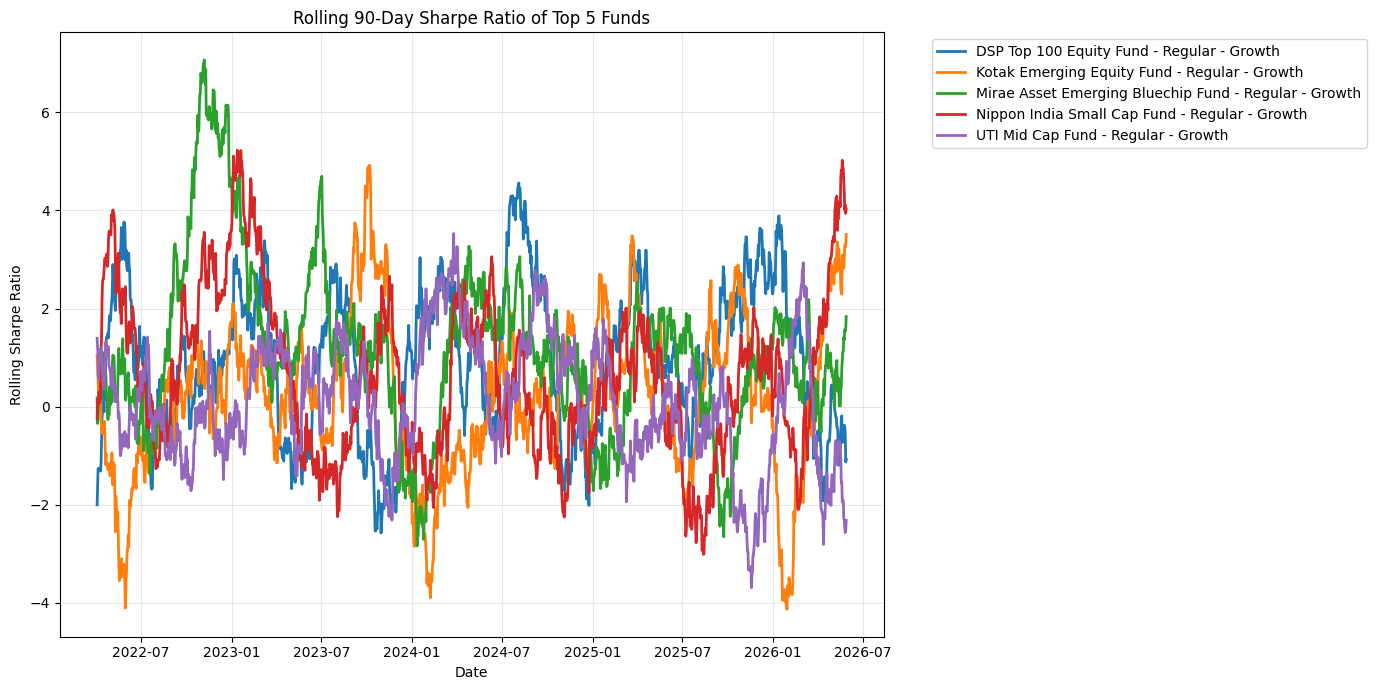

rolling_sharpe_chart.png saved successfully.


In [17]:
plt.figure(figsize=(14, 7))
for fund_name, fund_frame in (rolling_sharpe_df.groupby("scheme_name")):
    plt.plot(
        fund_frame["date"],
        fund_frame["rolling_sharpe"],
        linewidth=2,
        label=fund_name
    )
plt.title("Rolling 90-Day Sharpe Ratio of Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(bbox_to_anchor=(1.05, 1),loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/rolling_sharpe_chart.png",dpi=300,bbox_inches="tight")
plt.show()
print("rolling_sharpe_chart.png saved successfully.")

# DAY 6 - TASK 3
# Investor Cohort Analysis

In [18]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
first_activity = (transactions.groupby("investor_id")["transaction_date"].min().reset_index())
first_activity.rename(columns={"transaction_date": "first_transaction_date"},inplace=True)
first_activity.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [20]:
first_activity["cohort_year"] = (first_activity["first_transaction_date"].dt.year)
first_activity.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
transactions = (transactions.merge(
        first_activity[["investor_id", "cohort_year"]],on="investor_id",how="left"
    )
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [22]:
average_investment = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)
average_investment.rename(columns={"amount_inr": "avg_investment_amount"},inplace=True)
average_investment

,cohort_year,avg_investment_amount
0,2024,107422.541832
1,2025,109158.577061


In [23]:
total_investment = (transactions.groupby("cohort_year")["amount_inr"].sum().reset_index())
total_investment.rename(columns={"amount_inr": "total_invested_amount"},inplace=True)
total_investment

,cohort_year,total_invested_amount
0,2024,3491125187
1,2025,30455243


In [24]:
fund_preference = (transactions.groupby(["cohort_year", "amfi_code"]).size()
    .reset_index(name="transaction_count")
)

In [25]:
scheme_lookup = scheme_data[["amfi_code", "scheme_name"]]
top_fund_data = (fund_preference
    .sort_values(by=["cohort_year","transaction_count"],ascending=[True, False])
    .groupby("cohort_year")
    .first()
    .reset_index()
)
top_fund_data = (top_fund_data.merge(scheme_lookup,on="amfi_code",how="left"))
top_fund_data.head()

,cohort_year,amfi_code,transaction_count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [26]:
cohort_analysis = (average_investment
    .merge(total_investment,on="cohort_year")
    .merge(top_fund_data[["cohort_year","scheme_name"]],on="cohort_year"))
cohort_analysis.rename(columns={"scheme_name": "top_fund_preference"},inplace=True)
cohort_analysis

,cohort_year,avg_investment_amount,total_invested_amount,top_fund_preference
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [27]:
cohort_analysis.to_csv("../reports/cohort_analysis.csv",index=False)
print("cohort_analysis.csv saved successfully.")

cohort_analysis.csv saved successfully.


# DAY 6 - TASK 4
# SIP Continuity Analysis

In [28]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
sip_transactions = (transactions[transactions["transaction_type"].str.upper().eq("SIP")].copy())
sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [29]:
sip_transactions = sip_transactions.sort_values(by=["investor_id","transaction_date"])
sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [30]:
sip_transactions["days_between_sips"] = (sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)
sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,days_between_sips
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [31]:
sip_counts = (sip_transactions.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count"))
sip_counts.head()

,investor_id,sip_transaction_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [32]:
eligible_investors = (sip_counts[sip_counts["sip_transaction_count"] >= 6])
eligible_investors.head()

,investor_id,sip_transaction_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [33]:
average_gap_data = (sip_transactions.groupby("investor_id")["days_between_sips"]
    .mean()
    .reset_index()
)
average_gap_data.rename(columns={"days_between_sips": "average_gap_days"},inplace=True)
average_gap_data.head()

,investor_id,average_gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [34]:
sip_continuity = (eligible_investors.merge(average_gap_data,on="investor_id",how="left"))
sip_continuity.head()

,investor_id,sip_transaction_count,average_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [35]:
sip_continuity["sip_status"] = (sip_continuity["average_gap_days"]
    .apply(
        lambda gap:
        "At-Risk"
        if gap > 35
        else "Active")
)
sip_continuity["sip_status"].value_counts()

sip_status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [36]:
sip_continuity.to_csv("../reports/sip_continuity.csv",index=False)
print("sip_continuity.csv saved successfully.")

sip_continuity.csv saved successfully.


# DAY 6 - TASK 6
# Sector Concentration Analysis (HHI)

In [38]:
sector_summary = (holdings_data.groupby(["amfi_code", "sector"])["weight_pct"].sum().reset_index())
sector_summary["sector_weight"] = (sector_summary["weight_pct"] / 100)
sector_summary.head()

,amfi_code,sector,weight_pct,sector_weight
0,100016,Automobile,14.84,0.1484
1,100016,Banking,3.39,0.0339
2,100016,Energy,6.09,0.0609
3,100016,FMCG,11.68,0.1168
4,100016,IT,25.90,0.2590


In [39]:
sector_hhi = (sector_summary
    .groupby("amfi_code")["sector_weight"]
    .apply(lambda weights:np.sum(weights ** 2))
    .reset_index(name="hhi_score")
)
sector_hhi.head()

,amfi_code,hhi_score
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [40]:
scheme_lookup = (scheme_data[["amfi_code", "scheme_name"]].drop_duplicates())
sector_hhi = (sector_hhi.merge(scheme_lookup,on="amfi_code",how="left"))
sector_hhi.head()

,amfi_code,hhi_score,scheme_name
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth


In [43]:
sector_hhi = (sector_hhi.sort_values(by="hhi_score",ascending=False))
def classify_concentration(hhi):
    if hhi >= 0.25:
        return "Highly Concentrated"
    elif hhi >= 0.15:
        return "Moderately Concentrated"
    else:
        return "Diversified"

sector_hhi["concentration_level"] = (sector_hhi["hhi_score"].apply(classify_concentration))
top_concentrated_funds = (sector_hhi.head(10))
top_concentrated_funds[["scheme_name","hhi_score","concentration_level"]]

,scheme_name,hhi_score,concentration_level
11,Axis Bluechip Fund - Regular - Growth,0.296769,Highly Concentrated
30,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,Highly Concentrated
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,Highly Concentrated
6,UTI Flexi Cap Fund - Regular - Growth,0.251383,Highly Concentrated
32,DSP Midcap Fund - Regular - Growth,0.241077,Moderately Concentrated
21,ICICI Pru Midcap Fund - Regular - Growth,0.238695,Moderately Concentrated
10,Nippon India ETF Nifty 50 BeES,0.237497,Moderately Concentrated
18,SBI Small Cap Fund - Direct Plan - Growth,0.232361,Moderately Concentrated
22,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464,Moderately Concentrated
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647,Moderately Concentrated


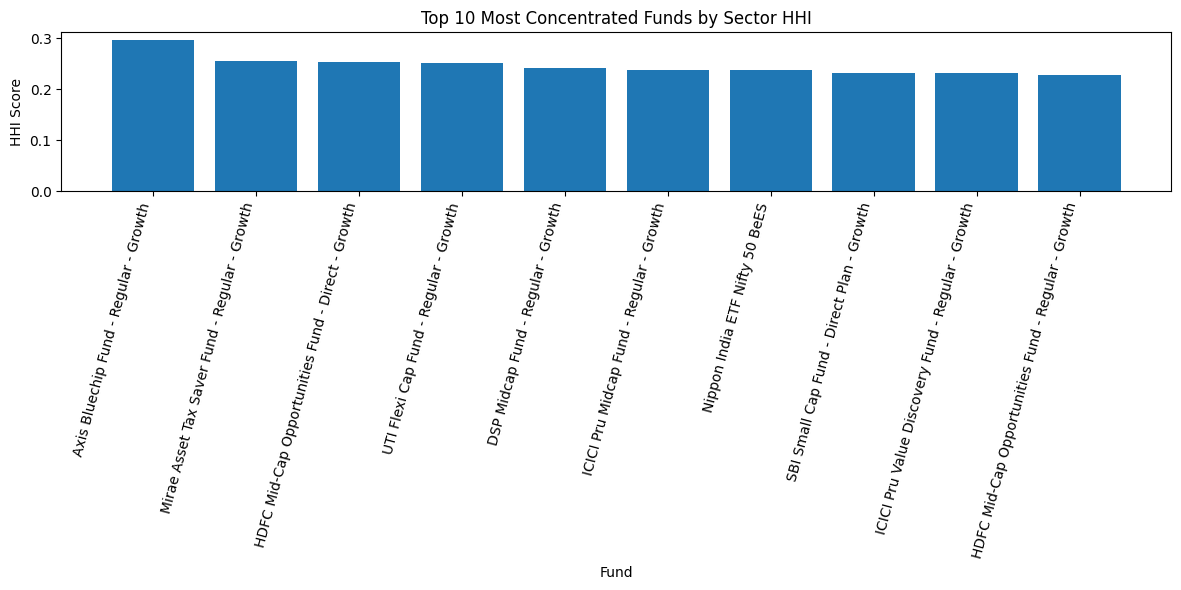

In [45]:
chart_data = sector_hhi.head(10)
plt.figure(figsize=(12, 6))
plt.bar(chart_data["scheme_name"],chart_data["hhi_score"])
plt.title("Top 10 Most Concentrated Funds by Sector HHI")
plt.xlabel("Fund")
plt.ylabel("HHI Score")
plt.xticks(rotation=75,ha="right")
plt.tight_layout()
plt.savefig("../reports/sector_hhi_chart.png",dpi=300,bbox_inches="tight")
plt.show()

In [46]:
sector_hhi.to_csv("../reports/sector_hhi.csv",index=False)
print("sector_hhi.csv saved successfully.")

sector_hhi.csv saved successfully.


# DAY 6 - TASK 7
# Advanced Analytics Summary & Key Insights

# Advanced Analytics Summary

## Insight 1 — Downside Risk Assessment

Historical Value at Risk (VaR) analysis highlighted the funds that are most vulnerable to adverse market movements. Funds with the lowest VaR values exhibited greater downside exposure, indicating a higher probability of experiencing significant short-term losses during volatile market conditions.


## Insight 2 — Tail Risk Evaluation

Conditional Value at Risk (CVaR) provided additional insight into extreme loss scenarios. Certain schemes showed substantially lower CVaR values compared to peers, suggesting that losses can become considerably larger once the VaR threshold is breached. These funds require closer risk monitoring during market stress periods.


## Insight 3 — Investor Cohort Behaviour

Cohort analysis revealed that earlier investor groups contributed the largest share of invested capital. Investors who entered the market in earlier years demonstrated stronger participation levels and generated higher cumulative investment values compared to more recent cohorts.


## Insight 4 — SIP Continuity Trends

SIP continuity analysis indicated that the majority of investors maintained regular contribution patterns. However, a subset of investors exhibited average contribution gaps exceeding 35 days and were classified as At-Risk. These investors may require engagement initiatives to improve long-term retention.


## Insight 5 — Portfolio Concentration Risk

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) showed meaningful differences in diversification across funds. Funds with elevated HHI scores were more heavily concentrated in a limited number of sectors, increasing sensitivity to sector-specific market movements. Diversified funds generally displayed lower concentration risk and broader sector exposure.